# Miniproject 1 – Architecture 3: Regularized CNN

**Team Members:** Aurel Köppel, Yves Fricker

**Course:** Applications of AI (AiAp), OST, Spring 2026

---

Same architecture as in notebook 2 (identical layer counts, filter sizes, and 767,946 trainable parameters), but now with regularisation. We combine L2 weight decay, dropout and early stopping.

This notebook also contains the two additional evaluation steps required by the task description: a 5-fold cross-validation on the train+val portion, and the final test-set evaluation at the very end.

## 1. Imports and Setup

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Set Keras backend to TensorFlow
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers, regularizers, callbacks
from sklearn.model_selection import StratifiedKFold

# Import our shared helper functions
from helpers import (
    load_animals10,
    split_data,
    plot_learning_curves,
    plot_confusion_matrices,
    print_classification_metrics,
)

print(f"Keras version: {keras.__version__}")
print(f"Backend: {keras.backend.backend()}")

Keras version: 3.13.2
Backend: tensorflow


In [2]:
import kagglehub

# Download dataset automatically (cached after first download)
path = kagglehub.dataset_download("alessiocorrado99/animals10")
DATA_DIR = os.path.join(path, "raw-img")

X, y, class_names = load_animals10(
    data_dir=DATA_DIR,
    img_size=64,
    samples_per_class=1000,
    reduced_class="elefante",
    reduced_count=150,
    seed=42,
)

X_trainval, X_test, y_trainval, y_test = split_data(X, y, test_size=0.3, random_state=42)

NUM_CLASSES = len(class_names)
IMG_SIZE = 64

print(f"\nClasses: {class_names}")
print(f"Train+Val: {X_trainval.shape}, Test: {X_test.shape}")

  Loaded 1000 images for class 'dog' (folder: cane)
  Loaded 1000 images for class 'horse' (folder: cavallo)
  Loaded 150 images for class 'elephant' (folder: elefante)
  Loaded 1000 images for class 'butterfly' (folder: farfalla)
  Loaded 1000 images for class 'chicken' (folder: gallina)
  Loaded 1000 images for class 'cat' (folder: gatto)
  Loaded 1000 images for class 'cow' (folder: mucca)
  Loaded 1000 images for class 'sheep' (folder: pecora)
  Loaded 1000 images for class 'spider' (folder: ragno)
  Loaded 1000 images for class 'squirrel' (folder: scoiattolo)

Total: 9150 images, 10 classes
Train+Val: 6405 samples
Test:      2745 samples (locked away)

Classes: ['dog', 'horse', 'elephant', 'butterfly', 'chicken', 'cat', 'cow', 'sheep', 'spider', 'squirrel']
Train+Val: (6405, 64, 64, 3), Test: (2745, 64, 64, 3)


## 3. Model Definition

We rebuild the architecture from notebook 2 and add three regularisation mechanisms.

First, L2 weight decay on every Conv2D and Dense layer through `kernel_regularizer=regularizers.l2(lambda)`. L2 adds a `lambda * ||w||²` penalty to the loss, which pushes weights toward zero and makes the model prefer smoother solutions. We use `lambda = 1e-3`, chosen from the short sweep in section 4.

Second, dropout at two levels: `Dropout(0.25)` after each of the four conv blocks to stop the convolutional features from co-adapting, and a stronger `Dropout(0.5)` after the `Dense(256)` layer, where most of the parameters live and where most of the memorisation happens.

Third, an `EarlyStopping` callback on `val_loss` with `patience=10` and `restore_best_weights=True`, so training cannot drift past the optimum.

None of these add trainable parameters, so the model still has exactly 767,946 parameters, matching architecture 2.

In [3]:
def build_regularized_model(l2_lambda=1e-3, dropout_rate=0.5):
    """
    Build the regularized CNN. Same architecture as Notebook 2,
    but with L2 regularization and Dropout.

    Parameters
    ----------
    l2_lambda : float
        L2 regularization strength. Higher = stronger regularization.
    dropout_rate : float
        Fraction of neurons to drop in the Dense layer (between 0.1 and 0.5).

    Returns
    -------
    keras.Sequential
        Compiled model.
    """
    reg = regularizers.l2(l2_lambda)

    model = keras.Sequential([
        keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        # Block 1: same as Notebook 2, but with L2 regularization + Dropout
        layers.Conv2D(32, (3, 3), padding="same", activation="relu", kernel_regularizer=reg),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3, 3), padding="same", activation="relu", kernel_regularizer=reg),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3, 3), padding="same", activation="relu", kernel_regularizer=reg),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 4
        layers.Conv2D(128, (3, 3), padding="same", activation="relu", kernel_regularizer=reg),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Classification head with Dropout
        layers.Flatten(),
        layers.Dense(256, activation="relu", kernel_regularizer=reg),
        layers.Dropout(dropout_rate),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [4]:
# Build model with chosen hyperparameters
model = build_regularized_model(l2_lambda=1e-3, dropout_rate=0.5)
model.summary()

print(f"\nTotal trainable parameters: {model.count_params():,}")
print("Same number of trainable parameters as Architecture 2 (Dropout and L2 don't add parameters).")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 8, 8, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 767,946 (2.93 MB)

 Trainable params: 767,946 (2.93 MB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 767,946
Same number of trainable parameters as Architecture 2 (Dropout and L2 don't add parameters).


## 4. Exploring Regularization Effects

Before training the final model we do a short sweep over `lambda` to confirm we see the expected regimes. `lambda=0` should behave like notebook 2 (overfitting), a very large `lambda` should force underfitting, and an intermediate value should sit between the two.

We train only 15 epochs per value because we want the qualitative shape of the curves, not the final accuracy.


Training with lambda=0 (no reg.)...
  Final val accuracy: 0.526

Training with lambda=1e-3 (balanced)...
  Final val accuracy: 0.470

Training with lambda=1.0 (too strong)...
  Final val accuracy: 0.099


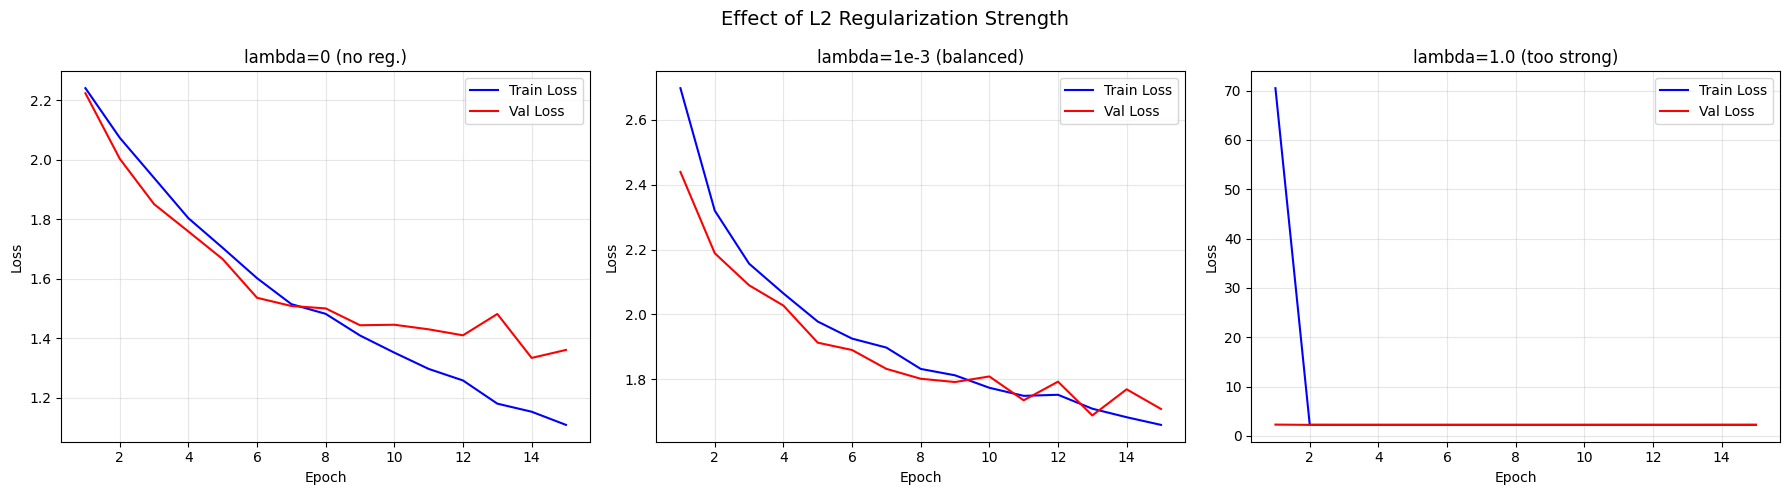

In [5]:
# Quick experiment: different lambda values
lambda_values = [0, 1e-3, 1.0]
lambda_labels = ["lambda=0 (no reg.)", "lambda=1e-3 (balanced)", "lambda=1.0 (too strong)"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, lam, label in zip(axes, lambda_values, lambda_labels):
    print(f"\nTraining with {label}...")
    temp_model = build_regularized_model(l2_lambda=lam, dropout_rate=0.5)
    temp_history = temp_model.fit(
        X_trainval, y_trainval,
        epochs=15, batch_size=32, validation_split=0.2, verbose=0,
    )

    epochs = range(1, 16)
    ax.plot(epochs, temp_history.history["loss"], "b-", label="Train Loss")
    ax.plot(epochs, temp_history.history["val_loss"], "r-", label="Val Loss")
    ax.set_title(label)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

    final_val_acc = temp_history.history["val_accuracy"][-1]
    print(f"  Final val accuracy: {final_val_acc:.3f}")

plt.suptitle("Effect of L2 Regularization Strength", fontsize=14)
plt.tight_layout()
plt.show()

The sweep matches expectations. With `lambda=0` the train and validation losses diverge, just like in notebook 2. With `lambda=1.0` both losses stay very high (the L2 penalty dominates and the network can barely fit anything). `lambda=1e-3` sits in between: smaller train-val gap, stable validation loss.

Note on the tuning method. We deliberately use a single train/validation split here rather than k-fold CV. CV-based hyperparameter search is more robust, but it requires training `k × n_candidates` models. For task s), which asks for a qualitative demonstration of the regularisation effect across three candidate values, a single split is sufficient. The 5-fold CV in section 10 is then used for its primary purpose: estimating the generalisation error of the final chosen model.

## 5. Train the Final Model

Chosen hyperparameters:
- `l2_lambda = 1e-3`
- `dropout_rate = 0.5` on the dense layer
- `Dropout(0.25)` after each conv block
- `EarlyStopping(patience=10, restore_best_weights=True)`

We train for up to 80 epochs. In practice EarlyStopping usually triggers before that and the best weights are restored automatically.

In [6]:
# Build fresh model with optimal hyperparameters
model = build_regularized_model(l2_lambda=1e-3, dropout_rate=0.5)

# EarlyStopping: stop when val_loss stops improving
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1,
)

history = model.fit(
    X_trainval,
    y_trainval,
    epochs=80,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/80
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.1509 - loss: 2.5880 - val_accuracy: 0.2077 - val_loss: 2.2686
Epoch 2/80
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.2283 - loss: 2.2100 - val_accuracy: 0.2904 - val_loss: 2.0783
Epoch 3/80
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.2730 - loss: 2.0711 - val_accuracy: 0.3208 - val_loss: 1.9766
Epoch 4/80
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.3064 - loss: 1.9711 - val_accuracy: 0.3544 - val_loss: 1.8809
Epoch 5/80
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.3296 - loss: 1.9192 - val_accuracy: 0.3731 - val_loss: 1.8499
Epoch 6/80
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.3527 - loss: 1.8967 - val_accuracy: 0.3958 - val_loss: 1.8159
Epoch 7/80
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.3819 - loss: 1.8464 - val_accuracy: 0.4091 - val_loss: 1.8051
Epoch 8/80
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.4102 - loss: 1.7796 - val_accu

In [7]:
# Print final training statistics
print("Final Training Statistics:")
print(f"  Training Loss:       {history.history['loss'][-1]:.4f}")
print(f"  Training Accuracy:   {history.history['accuracy'][-1]:.4f}")
print(f"  Validation Loss:     {history.history['val_loss'][-1]:.4f}")
print(f"  Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

Final Training Statistics:
  Training Loss:       1.3905
  Training Accuracy:   0.6146
  Validation Loss:     1.5955
  Validation Accuracy: 0.5472


## 6. Learning Curves

Compared to notebook 2 we expect a visibly smaller train-val gap and a validation loss that plateaus or keeps slowly decreasing instead of climbing. The training loss will not reach zero because L2 contributes a non-vanishing penalty term (the total reported loss is `data_loss + lambda * ||w||²`).

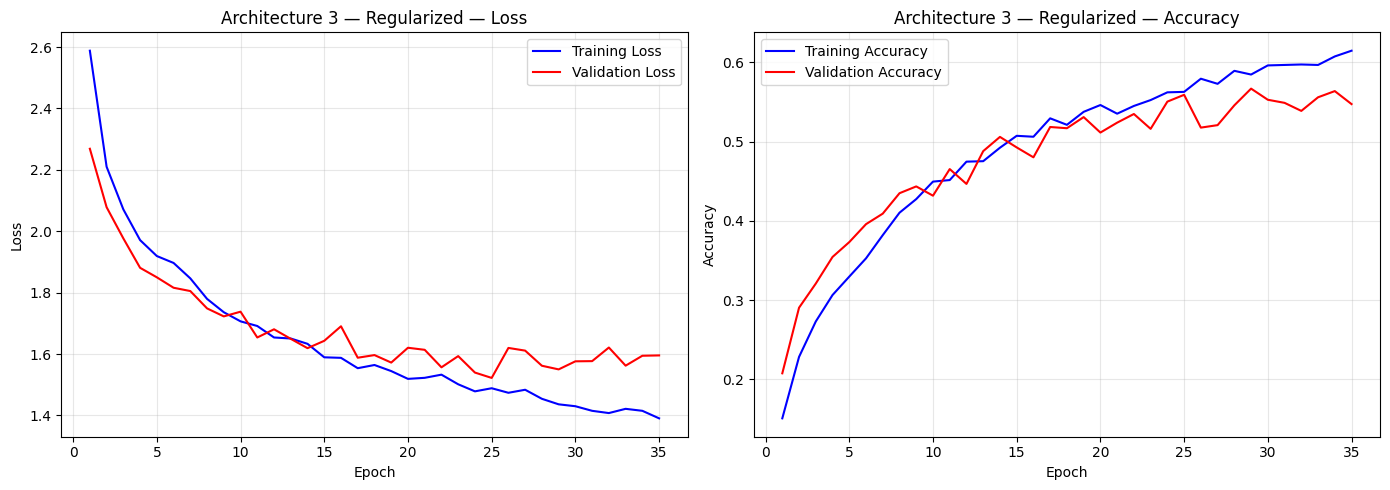

In [8]:
plot_learning_curves(history, title="Architecture 3 — Regularized")

## 7. Confusion Matrices

In [9]:
val_split = int(len(X_trainval) * 0.8)
X_val = X_trainval[val_split:]
y_val = y_trainval[val_split:]

y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

print(f"Validation set size: {len(X_val)}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Validation set size: 1281


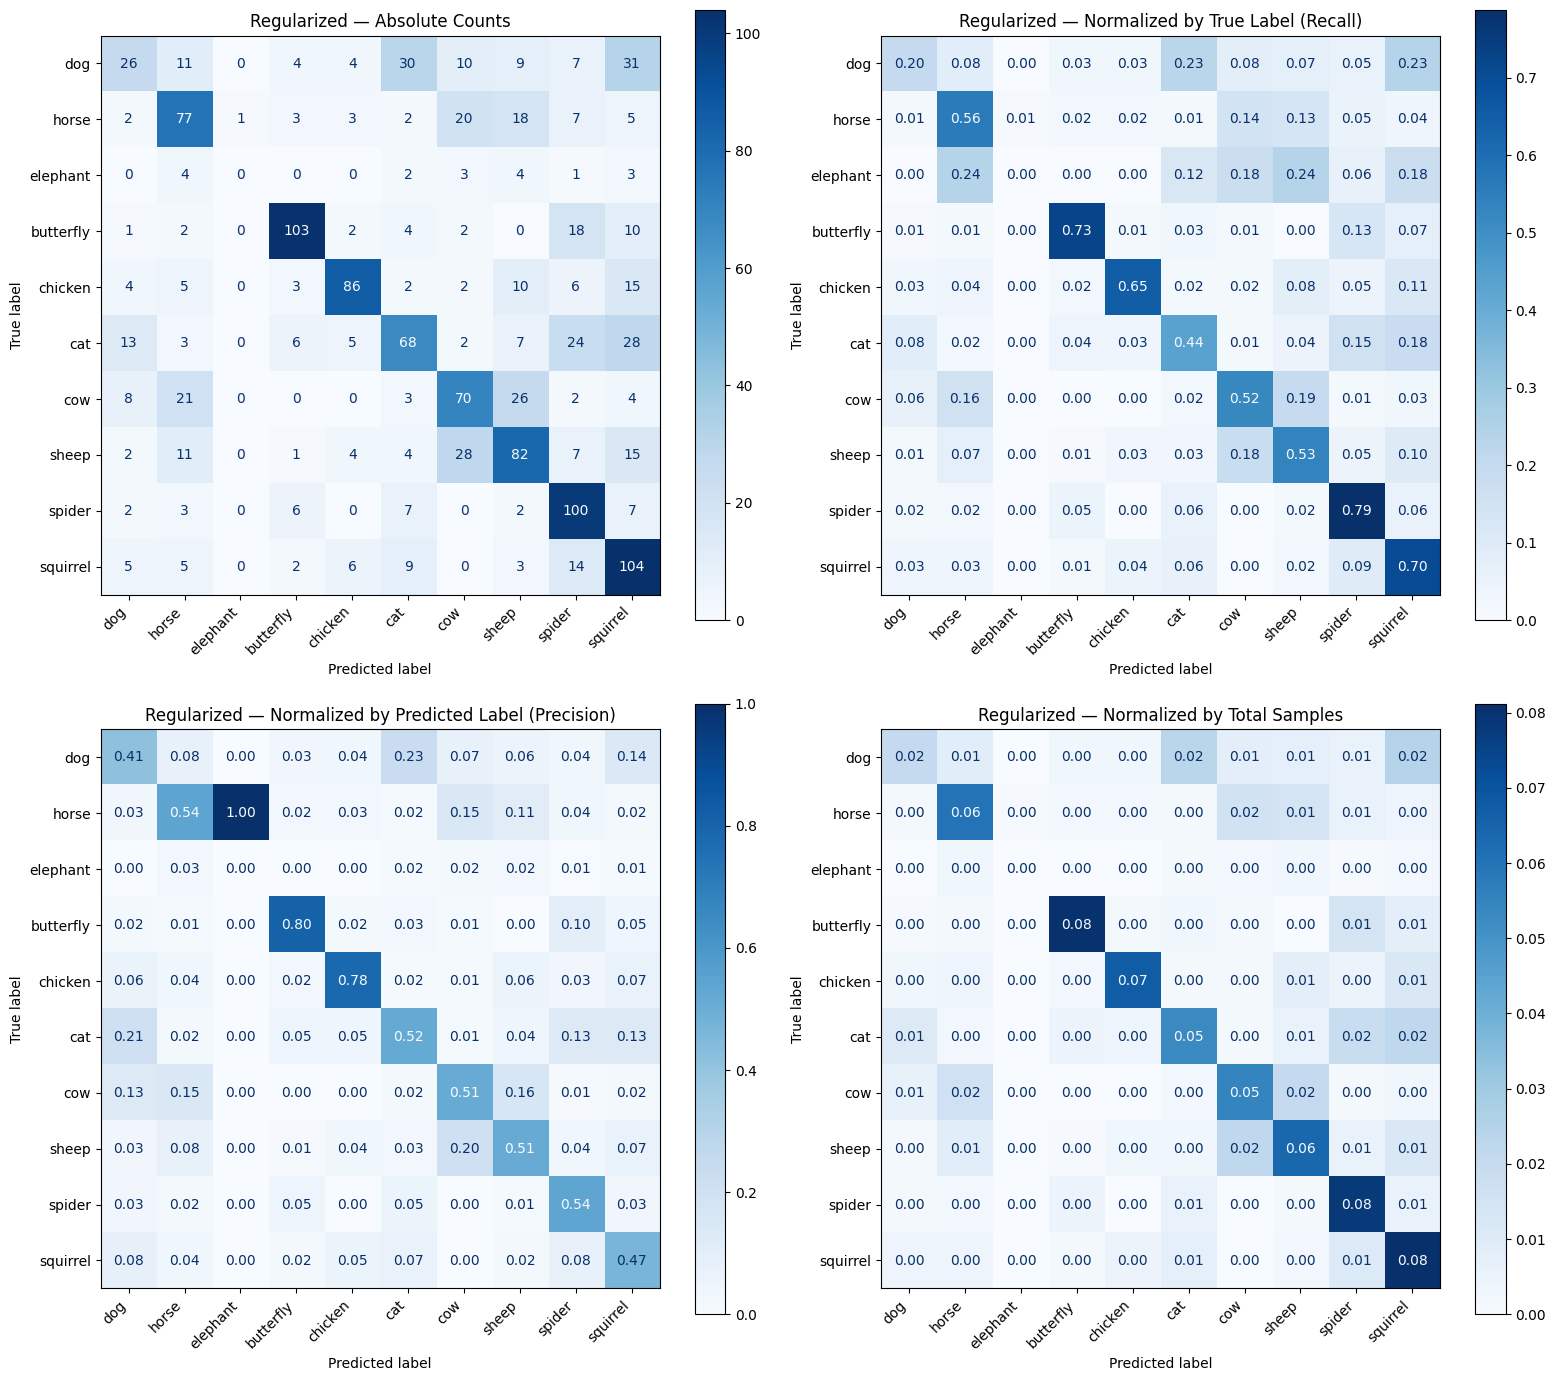

In [10]:
plot_confusion_matrices(y_val, y_pred, class_names, title_prefix="Regularized — ")

### What the matrix shows

The diagonal is generally stronger than in notebook 2 for the high-performing classes, and the off-diagonal mass is more evenly spread instead of being concentrated in a few columns. Butterfly, chicken and spider stand out with the cleanest diagonals. The mammal block (dog, cat, cow, sheep, horse) still gets tangled, but the individual recalls are in a more balanced range than under the unregularised model.

Interestingly, spider and squirrel show the largest gap between recall and precision: spider recall is very high (around 0.79) but precision only around 0.54, and squirrel sits around 0.70 / 0.47. Their columns are over-populated: the model picks these classes as a fallback when uncertain. Dog is the opposite case, recall collapses to around 20 % while precision stays moderate, so the model simply predicts "dog" rarely. Elephant again hits 0 / 0, confirming that no amount of regularisation helps when there is not enough training signal for that class.

## 8. Classification Metrics

In [11]:
print_classification_metrics(y_val, y_pred, class_names)

Classification Report:
              precision    recall  f1-score   support

         dog      0.413     0.197     0.267       132
       horse      0.542     0.558     0.550       138
    elephant      0.000     0.000     0.000        17
   butterfly      0.805     0.725     0.763       142
     chicken      0.782     0.647     0.708       133
         cat      0.519     0.436     0.474       156
         cow      0.511     0.522     0.517       134
       sheep      0.509     0.532     0.521       154
      spider      0.538     0.787     0.639       127
    squirrel      0.468     0.703     0.562       148

    accuracy                          0.559      1281
   macro avg      0.509     0.511     0.500      1281
weighted avg      0.557     0.559     0.547      1281



## 9. Discussion of the Regularized Model

The train-val gap is much smaller than in notebook 2 and the validation loss no longer diverges, it settles into a plateau. Training accuracy now stays well below the ~99 % we saw without regularisation, which is exactly what we want: dropout randomly disables neurons at every step, and L2 prevents any single weight from growing large, so the model cannot memorise individual training examples as aggressively as before.

EarlyStopping triggered before the full 80 epochs (the exact epoch varies between runs) and rolled the weights back to the best-`val_loss` checkpoint. This means the metrics from the very last reported epoch are often slightly worse than the metrics we actually use, which are from the best epoch.

Elephant is still the weakest class. This is not a regularisation problem, it is a data problem. 150 samples simply are not enough to learn a robust representation. Proper fixes would be class weights, oversampling or targeted data augmentation, which are out of scope here.

## 10. 5-Fold Cross-Validation

A single train/val split gives one point estimate of the generalisation error, which can be optimistic or pessimistic depending on which samples happen to land in the validation fold. 5-fold CV gives us a distribution over that estimate instead.

We use `StratifiedKFold` on the 70 % train+val portion, so each fold keeps the class proportions intact. For every fold we build a fresh model (fresh weights, fresh optimiser state), train with EarlyStopping and evaluate on the held-out fold. The mean and standard deviation across the five runs summarise how much the model's performance depends on the specific split.

The 30 % test set stays locked at this point.

In [12]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_losses = []
cv_accuracies = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval)):
    print(f"\n{'='*50}")
    print(f"Fold {fold + 1}/5")
    print(f"{'='*50}")

    X_train_fold = X_trainval[train_idx]
    y_train_fold = y_trainval[train_idx]
    X_val_fold = X_trainval[val_idx]
    y_val_fold = y_trainval[val_idx]

    print(f"Train: {len(X_train_fold)}, Val: {len(X_val_fold)}")

    # Build a fresh model for each fold
    fold_model = build_regularized_model(l2_lambda=1e-3, dropout_rate=0.5)

    # EarlyStopping for each fold
    fold_early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=0,
    )

    fold_model.fit(
        X_train_fold, y_train_fold,
        epochs=80,
        batch_size=32,
        validation_data=(X_val_fold, y_val_fold),
        callbacks=[fold_early_stop],
        verbose=0,
    )

    # Evaluate on the validation fold
    loss, accuracy = fold_model.evaluate(X_val_fold, y_val_fold, verbose=0)
    cv_losses.append(loss)
    cv_accuracies.append(accuracy)
    print(f"Fold {fold + 1} — Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

print(f"\n{'='*50}")
print(f"Cross-Validation Results (5-Fold)")
print(f"{'='*50}")
print(f"Loss:     {np.mean(cv_losses):.4f} ± {np.std(cv_losses):.4f}")
print(f"Accuracy: {np.mean(cv_accuracies):.4f} ± {np.std(cv_accuracies):.4f}")


Fold 1/5
Train: 5124, Val: 1281
Fold 1 — Loss: 1.5198, Accuracy: 0.5902

Fold 2/5
Train: 5124, Val: 1281
Fold 2 — Loss: 1.4970, Accuracy: 0.5582

Fold 3/5
Train: 5124, Val: 1281
Fold 3 — Loss: 1.5082, Accuracy: 0.5691

Fold 4/5
Train: 5124, Val: 1281
Fold 4 — Loss: 1.5288, Accuracy: 0.5464

Fold 5/5
Train: 5124, Val: 1281
Fold 5 — Loss: 1.4428, Accuracy: 0.6128

Cross-Validation Results (5-Fold)
Loss:     1.4993 ± 0.0302
Accuracy: 0.5753 ± 0.0236


### Cross-Validation Discussion

The 5-fold CV results give us a confidence interval around the model's true performance:
- The mean accuracy is our best estimate of performance on unseen data.
- The standard deviation tells us how much the performance varies across splits.
- A low std indicates a model that is stable with respect to the split; a high std would suggest the opposite.

Concrete consistency check. The CV mean accuracy (around 0.575 ± 0.024) is close to the single-split validation accuracy from section 8 (around 0.559), a difference of only about 0.016, well within 1σ. The CV loss (around 1.50 ± 0.03) sits in the same range as the validation loss from the single split. So the single validation split was not an outlier, and the numbers reported in sections 6–8 are not artifacts of a lucky or unlucky shuffle. The standard deviation of about 2.4 percentage points on accuracy indicates that the model is reasonably stable under different splits, though with somewhat more run-to-run variation than a tighter bound would suggest.

## 11. Final Evaluation on Test Set

We now unlock the 30 % test set for the first and only time. We evaluate the model trained in section 5 (trained on the full train+val with the fixed split, not re-trained after CV) on this held-out data to get the actual generalisation performance we would report in a real project.

In [14]:
# Evaluate the model (from Section 5) on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

cv_acc_mean = np.mean(cv_accuracies)
cv_acc_std = np.std(cv_accuracies)
z_score = (test_accuracy - cv_acc_mean) / cv_acc_std

print(f"Test Set Results:")
print(f"  Loss:     {test_loss:.4f}")
print(f"  Accuracy: {test_accuracy:.4f}")

print("\nComparison with 5-Fold CV:")
print(f"  CV Loss:     {np.mean(cv_losses):.4f} ± {np.std(cv_losses):.4f}")
print(f"  CV Accuracy: {cv_acc_mean:.4f} ± {cv_acc_std:.4f}")
print(f"  Test accuracy z-score vs CV: {z_score:+.2f} sigma")

print("\nInterpretation:")
if abs(z_score) < 2:
    print(f"  Test accuracy ({test_accuracy:.4f}) lies within mean ± 2*sigma of the CV estimate.")
    if test_accuracy >= cv_acc_mean:
        print(f"  It even slightly exceeds the CV mean - the model generalizes as expected,")
        print(f"  with no sign of test-set pessimism or hidden distribution drift.")
    else:
        print(f"  It is slightly below the CV mean but well within statistical noise -")
        print(f"  the model generalizes as expected, no sign of test-set drift.")
else:
    print(f"  Test accuracy is OUTSIDE mean ± 2*sigma - possible distribution shift or unlucky split.")

Test Set Results:
  Loss:     1.5444
  Accuracy: 0.5581

Comparison with 5-Fold CV:
  CV Loss:     1.4993 ± 0.0302
  CV Accuracy: 0.5753 ± 0.0236
  Test accuracy z-score vs CV: -0.73 sigma

Interpretation:
  Test accuracy (0.5581) lies within mean ± 2*sigma of the CV estimate.
  It is slightly below the CV mean but well within statistical noise -
  the model generalizes as expected, no sign of test-set drift.


86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


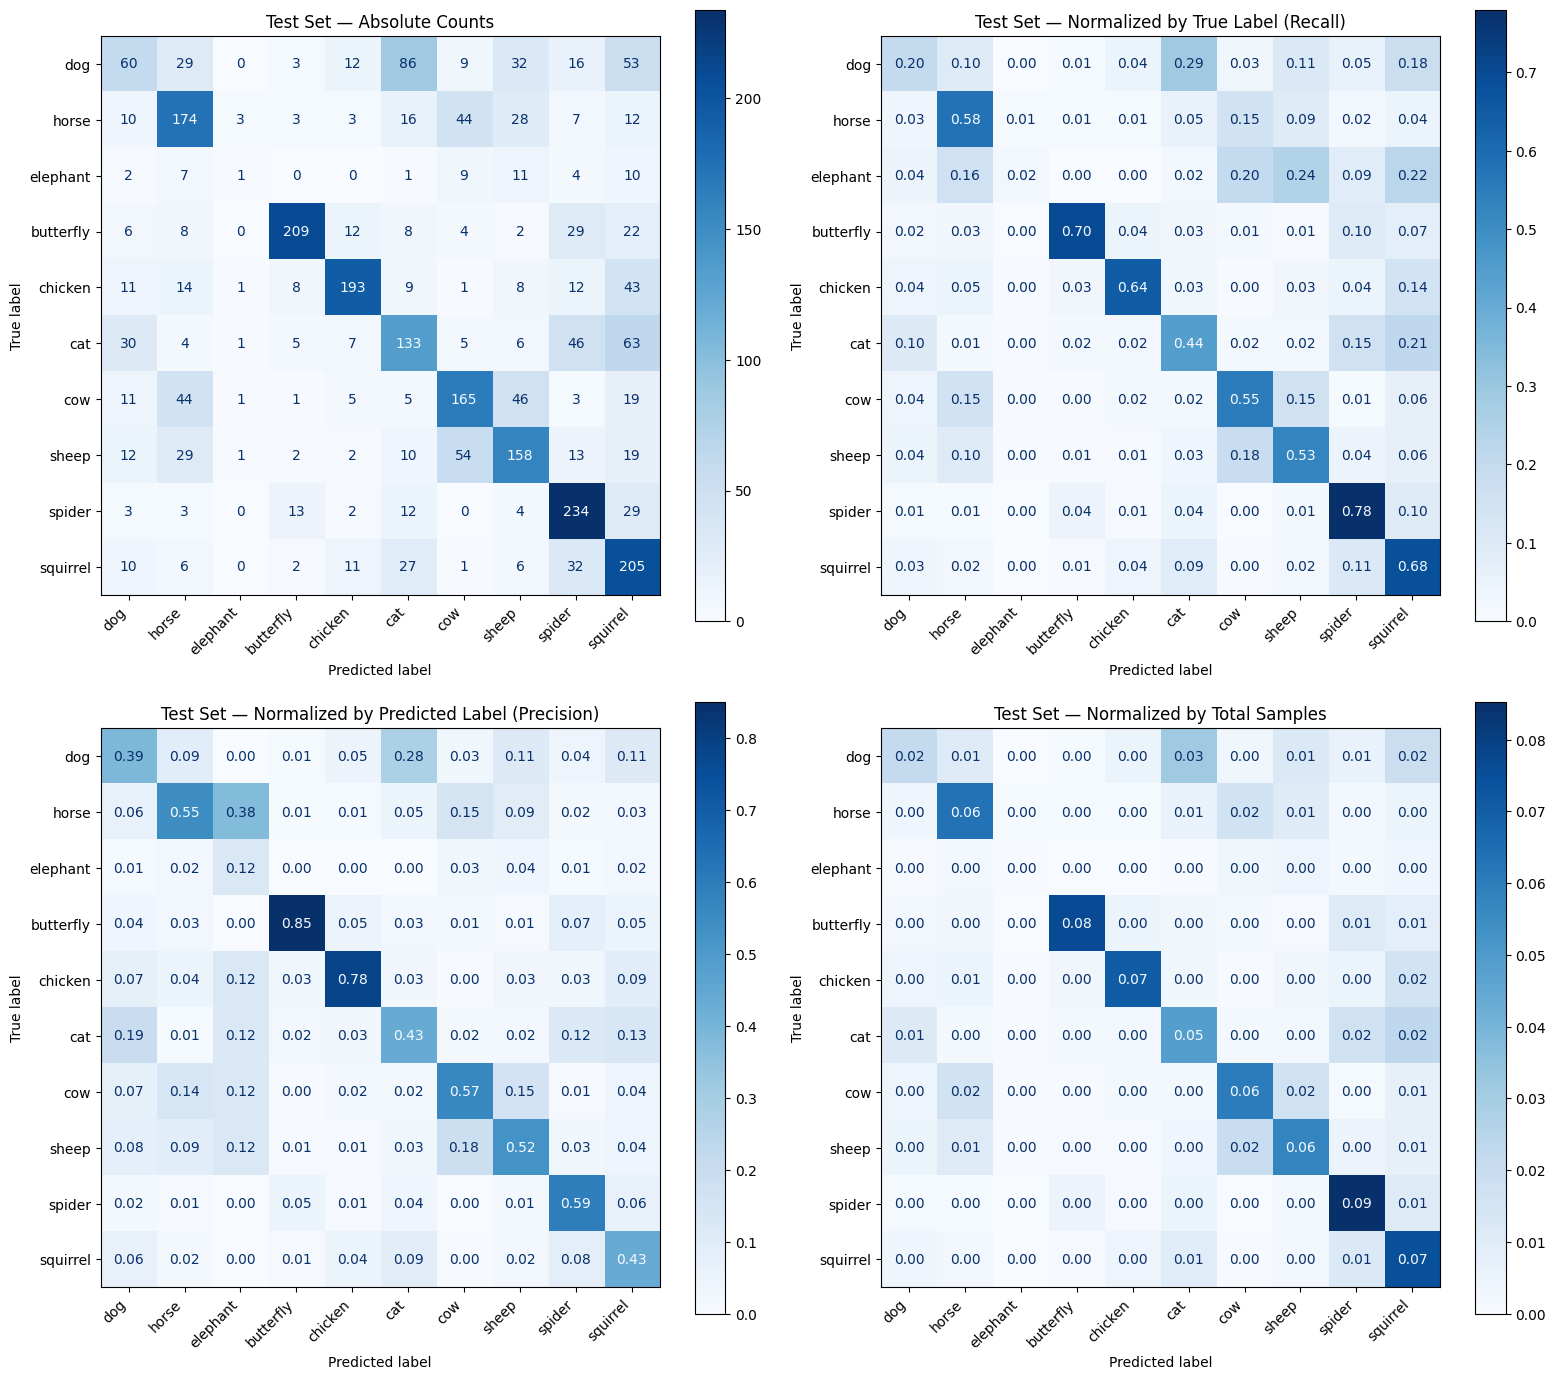

In [15]:
# Detailed test set metrics
y_test_pred_probs = model.predict(X_test)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)

plot_confusion_matrices(y_test, y_test_pred, class_names, title_prefix="Test Set — ")

### What the matrix shows on the test set

The test matrix looks very similar to the validation matrix: the same classes dominate the diagonal (butterfly, spider, chicken), the same mammal cluster remains tangled, and elephant again has near-zero recall (around 2 % on 45 test samples). The numbers sit close to both the CV estimate and the single-split validation, so the test result is not a new failure mode, the model behaves on held-out data as we observed during training.

All the patterns visible during validation reappear here. Dog has the lowest recall among the non-imbalanced classes (around 20 %). Spider and squirrel are over-predicted (their columns are too wide: recall is notably higher than precision). Elephant is almost never predicted. Nothing about the test matrix contradicts the regularised-model behaviour we described from the validation data.

In [16]:
print_classification_metrics(y_test, y_test_pred, class_names)

Classification Report:
              precision    recall  f1-score   support

         dog      0.387     0.200     0.264       300
       horse      0.547     0.580     0.563       300
    elephant      0.125     0.022     0.038        45
   butterfly      0.850     0.697     0.766       300
     chicken      0.781     0.643     0.706       300
         cat      0.433     0.443     0.438       300
         cow      0.565     0.550     0.557       300
       sheep      0.525     0.527     0.526       300
      spider      0.591     0.780     0.672       300
    squirrel      0.432     0.683     0.529       300

    accuracy                          0.558      2745
   macro avg      0.524     0.513     0.506      2745
weighted avg      0.561     0.558     0.549      2745



## 12. Final Discussion and Conclusions

| | Arch. 1 (Underfit) | Arch. 2 (Overfit) | Arch. 3 (Regularized) |
|---|---|---|---|
| Parameters | ~1,700 | ~768,000 | ~768,000 |
| Regularization | None | None | Dropout + L2 + EarlyStopping |
| Training accuracy | ~45 % | ~99 % | ~62 % |
| Validation accuracy | ~37 % | ~52 % | ~56 % |
| Test accuracy | – | – | 0.56 |
| CV accuracy | – | – | 0.575 ± 0.024 |
| Train-val gap | small | very large | small |
| Validation loss | high | diverges | stable |
| Failure mode | high bias | high variance | balanced |

Running the three architectures back to back gave us a fairly clean illustration of the classical bias–variance picture. Architecture 1 was too small to learn much of anything: its train and validation curves tracked each other closely but both plateaued at low accuracy. Architecture 2 had roughly 450× the parameters and happily memorised the training set to about 99 % accuracy while the validation accuracy stagnated around 52 %. Architecture 3 used the same number of parameters as architecture 2 but added dropout, L2 and early stopping, which lifted validation accuracy to around 56 % and stabilised the validation loss.

The most interesting observation from this comparison is that validation accuracy on its own is not a great metric for comparing the overfit and the regularised model. The gap in validation accuracy between architectures 2 and 3 is only a few percentage points (around 52 % vs 56 %), but the losses tell a very different story. Architecture 2's validation loss keeps climbing throughout training, which tells us the model is making high-confidence wrong predictions: even when the argmax is correct for many samples, the other predictions are confidently off, and cross-entropy penalises them heavily. Architecture 3's loss stabilises, so the predictions are better calibrated. In practice this matters for any downstream use that relies on the probabilities (calibrated thresholds, uncertainty estimates), so the loss is the more honest metric here.

The class imbalance stays problematic in every architecture. Elephant has 150 samples against 1000 for the other classes, and none of the three models manage any meaningful recall on it: validation recall sits at 0 throughout, and on the test set it only lifts to around 2 %, which is not useful. That is expected: regularisation and capacity tuning do not fix a missing signal in the data. Class weighting, oversampling or targeted augmentation would be the real remedy.

The three generalisation estimates we now have agree well: 5-fold cross-validation accuracy 0.575 ± 0.024, single-split validation accuracy 0.559, final test accuracy 0.558. All three values cluster within about two percentage points of each other. That consistency is itself informative: our validation split was not an outlier, the regularisation did not overfit to the specific validation fold, and the test-set estimate lines up with the CV estimate. Put differently, the result is reproducible across different ways of holding out data.

One thing we did not do is use cross-validation for hyperparameter search (the optional extension of task w). We tuned `lambda` with a single train/val split on three candidate values. For a broader sweep or for hyperparameters with stronger interactions (e.g. dropout rate × lambda × learning rate), a proper CV grid would be worth the extra compute.